In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("placement.csv")

In [3]:
df.head

<bound method NDFrame.head of     Unnamed: 0  cgpa     iq  placement
0            0   6.8  123.0          1
1            1   5.9  106.0          0
2            2   5.3  121.0          0
3            3   7.4  132.0          1
4            4   5.8  142.0          0
..         ...   ...    ...        ...
95          95   4.3  200.0          0
96          96   4.4   42.0          0
97          97   6.7  182.0          1
98          98   6.3  103.0          1
99          99   6.2  113.0          1

[100 rows x 4 columns]>

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [5]:
df.shape

(100, 4)

In [6]:
df = df.iloc[:,1:]

In [7]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [8]:
# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [23]:
import matplotlib as mpl

mpl.rcParams['font.enable_last_resort'] = False

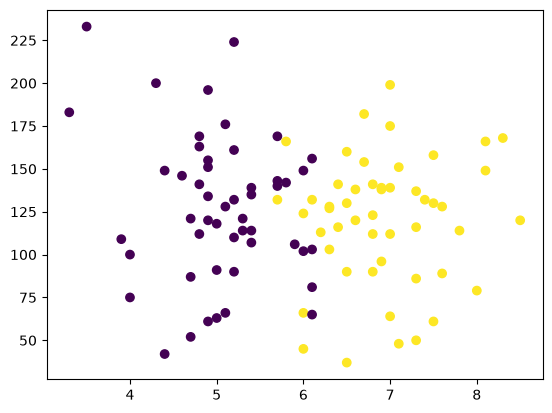

In [24]:
import matplotlib.pyplot as plt

plt.scatter(df['cgpa'], df['iq'], c=df['placement'])
plt.show()

In [25]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [26]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [27]:
y.shape

(100,)

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1)

In [30]:
X_train

,cgpa,iq
52,7.0,175.0
23,4.7,87.0
14,6.1,103.0
33,6.0,149.0
31,3.9,109.0
...,...,...
5,7.1,48.0
95,4.3,200.0
77,7.3,50.0
46,5.3,114.0


In [31]:
X_test

,cgpa,iq
57,6.5,130.0
43,6.8,141.0
61,7.3,137.0
96,4.4,42.0
19,5.2,132.0
26,7.0,199.0
66,6.9,96.0
7,5.0,63.0
76,4.9,155.0
93,6.8,112.0


In [32]:
from sklearn.preprocessing import StandardScaler

In [33]:
scaler = StandardScaler()

In [34]:
X_train = scaler.fit_transform(X_train)

In [35]:
X_train

array([[ 8.86016806e-01,  1.29813627e+00],
       [-1.11404294e+00, -9.37401726e-01],
       [ 1.03384731e-01, -5.30940273e-01],
       [ 1.64256115e-02,  6.37636404e-01],
       [-1.80971590e+00, -3.78517228e-01],
       [-7.66206464e-01,  1.04155747e-01],
       [ 6.25139448e-01,  7.64655609e-01],
       [-5.92288225e-01, -7.36711384e-02],
       [ 1.32081240e+00,  8.66270972e-01],
       [ 7.99057687e-01,  3.58194155e-01],
       [-6.79247344e-01, -8.61190204e-01],
       [-1.11404294e+00, -1.82653615e+00],
       [-5.05329105e-01, -4.29324910e-01],
       [-1.72275678e+00, -6.07151795e-01],
       [-6.79247344e-01,  9.42482494e-01],
       [-2.44451747e-01,  1.14571322e+00],
       [-2.44451747e-01,  2.05771111e-01],
       [ 1.40777152e+00,  1.04155747e-01],
       [-5.05329105e-01,  3.83597996e-01],
       [-9.40124703e-01,  2.56578792e-01],
       [ 1.03384731e-01,  2.05771111e-01],
       [-1.72275678e+00, -1.24224782e+00],
       [ 1.75560800e+00, -1.14063245e+00],
       [-1.

In [36]:
X_test = scaler.transform(X_test)

In [37]:
X_test

array([[ 0.45122121,  0.15496343],
       [ 0.71209857,  0.43440568],
       [ 1.14689416,  0.33279031],
       [-1.3749203 , -2.08057456],
       [-0.67924734,  0.20577111],
       [ 0.88601681,  1.90782845],
       [ 0.79905769, -0.70876716],
       [-0.85316558, -1.54709391],
       [-0.9401247 ,  0.79005945],
       [ 0.71209857, -0.30230571]])

In [38]:
from sklearn.linear_model import LogisticRegression

In [39]:
clf = LogisticRegression()

In [40]:
# Model Training
clf.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [41]:
y_pred = clf.predict(X_test)

In [42]:
y_pred

array([1, 1, 1, 0, 0, 1, 1, 0, 0, 1])

In [43]:
y_test

57    1
43    1
61    1
96    0
19    0
26    1
66    1
7     0
76    0
93    1
Name: placement, dtype: int64

In [44]:
from sklearn.metrics import accuracy_score

In [45]:
accuracy_score(y_test,y_pred)

1.0